# Load Dataset

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import nltk

import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from modules.data_loader import load_data

train_texts, train_labels, test_texts, test_labels,_ = load_data("ag_news")
print("Train:", len(train_texts), "Test:", len(test_texts))

Train: 120000 Test: 7600


In [33]:
import pandas as pd

train_df = pd.DataFrame({"text": train_texts, "label": train_labels})
test_df  = pd.DataFrame({"text": test_texts, "label": test_labels})

train_df.head()
test_df.head()

,text,label
0,Fears for T N pension after talks Unions repre...,2
1,The Race is On: Second Private Team Sets Launc...,3
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3


# Basic EDA
- Check missing feature
- Check duplicated text
- Map label to class name for clarify

In [34]:
print("Check missing value in train dataset:" )
print(train_df.isna().sum(), "\n")

print("Check missing value in test dataset:" )
print(test_df.isna().sum(), "\n")

train_duplicates = train_df.duplicated(subset=['text']).sum()
test_duplicates = test_df.duplicated(subset=['text']).sum()
print(f"\nDuplicate texts in train: {train_duplicates}")
print(f"Duplicate texts in test: {test_duplicates}")

label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}
train_df['label_name'] = train_df['label'].map(label_names)
test_df['label_name'] = test_df['label'].map(label_names)

train_df.head()

Check missing value in train dataset:
text     0
label    0
dtype: int64 

Check missing value in test dataset:
text     0
label    0
dtype: int64 


Duplicate texts in train: 0
Duplicate texts in test: 0


,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## Summary:
- The dataset is clean: there are no missing values and no duplicate texts in both train and test sets.


#  EDA

## Class distribution

Class distribution (train):
label_name
Business    0.25
Sci/Tech    0.25
Sports      0.25
World       0.25
Name: count, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_14448\3834036453.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_14448\3834036453.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


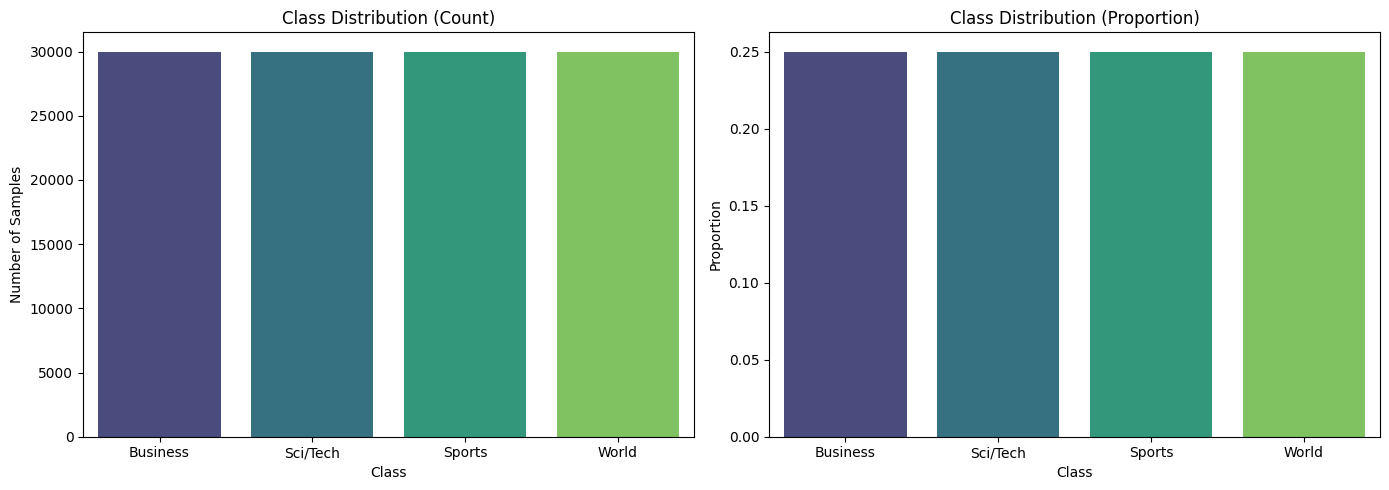

In [35]:
class_dist = train_df['label_name'].value_counts().sort_index()
print("Class distribution (train):")
print(class_dist/train_df.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    x=class_dist.index,
    y=class_dist.values,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')

sns.barplot(
    x=class_dist.index,
    y=class_dist.values / train_df.shape[0],
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Class Distribution (Proportion)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

### Summary
-The class distribution is perfectly balanced, with each category contributing 25% of the data. This ensures no class imbalance and helps the model learn all classes equally without bias.

## Word count in "Text" feature

Word count summary (train):
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: word_count, dtype: float64


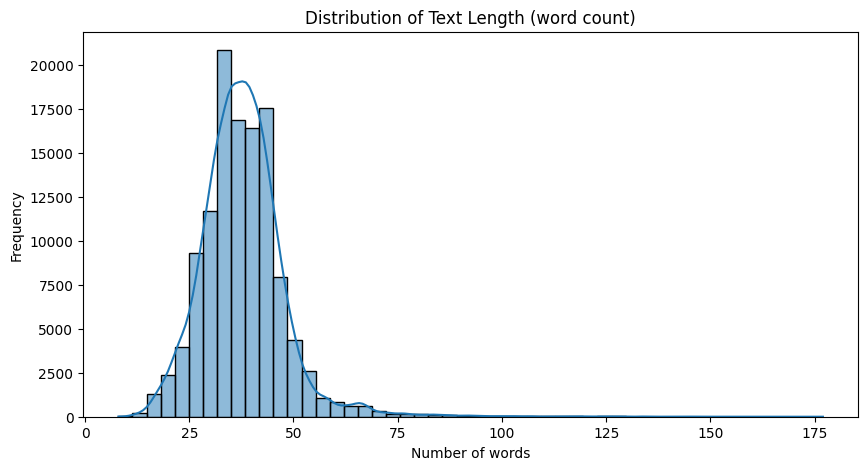

In [36]:
def word_count(text):
    return len(str(text).split())

train_df['word_count'] = train_df['text'].apply(word_count)
test_df['word_count'] = test_df['text'].apply(word_count)

# Summary statistics
print("Word count summary (train):")
print(train_df['word_count'].describe())

# Histogram of word counts
plt.figure(figsize=(10,5))
sns.histplot(train_df['word_count'], bins=50, kde=True)
plt.title('Distribution of Text Length (word count)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.show()

### Summary:
- The text length is relatively consistent, with an average of ~38 words per sample. Most texts fall between 32–43 words, indicating low variability, though a few longer outliers exist (up to 177 words).

## Word Frequency Per Class

In [37]:
# Preprocessing function: lowercase and remove non-alphabetic tokens? Let's keep words with letters only.
def clean_text(text):
    tokens = re.findall(r'\b[a-z]+\b', text.lower())
    return tokens

# Build vocabulary per class
class_words = {name: [] for name in label_names.values()}

for idx, row in train_df.iterrows():
    words = clean_text(row['text'])
    class_words[row['label_name']].extend(words)

# Get top 10 words per class
top_words_per_class = {}
for class_name, words in class_words.items():
    counter = Counter(words)
    top_words_per_class[class_name] = counter.most_common(10)

# Display
for class_name, top_words in top_words_per_class.items():
    print(f"\nTop 10 words in {class_name}:")
    for word, freq in top_words:
        print(f"  {word}: {freq}")


Top 10 words in World:
  the: 49041
  in: 32217
  to: 31139
  a: 30823
  of: 28983
  and: 17659
  s: 17237
  on: 16209
  for: 11638
  said: 7745

Top 10 words in Sports:
  the: 63390
  to: 27683
  a: 26123
  in: 24050
  of: 20393
  and: 15859
  s: 14389
  for: 13903
  on: 12359
  at: 9358

Top 10 words in Business:
  the: 44820
  to: 30221
  a: 29097
  of: 22781
  in: 22300
  and: 17190
  on: 16780
  s: 16660
  for: 12165
  its: 9567

Top 10 words in Sci/Tech:
  the: 48227
  to: 31703
  a: 27310
  of: 26495
  and: 18970
  in: 17858
  s: 13698
  for: 12968
  on: 12319
  that: 9464


## Top N-grams (Bigrams) per Class

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

# Function to get top n-grams for a given class
def get_top_ngrams(corpus, n=2, top_k=10):
    vec = CountVectorizer(ngram_range=(n,n), stop_words='english', max_features=1000).fit(corpus)
    bow = vec.transform(corpus)
    sum_words = bow.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# For each class, extract top bigrams
top_bigrams_per_class = {}
for class_name in label_names.values():
    class_corpus = train_df[train_df['label_name'] == class_name]['text']
    top_bigrams = get_top_ngrams(class_corpus, n=2, top_k=10)
    top_bigrams_per_class[class_name] = top_bigrams

# Display
for class_name, bigrams in top_bigrams_per_class.items():
    print(f"\nTop 10 bigrams in {class_name}:")
    for bg, freq in bigrams:
        print(f"  {bg}: {freq}")


Top 10 bigrams in World:
  ap ap: 2759
  prime minister: 2321
  lt gt: 2199
  afp afp: 1512
  reuters reuters: 1419
  gt lt: 1100
  president bush: 942
  canadian press: 905
  united states: 903
  officials said: 892

Top 10 bigrams in Sports:
  ap ap: 3076
  new york: 1719
  red sox: 1452
  sports network: 1255
  lt gt: 1216
  world cup: 827
  gt lt: 617
  united states: 565
  manchester united: 563
  gold medal: 552

Top 10 bigrams in Business:
  new york: 3387
  lt gt: 3316
  oil prices: 2555
  york reuters: 1839
  href http: 1819
  lt href: 1818
  http www: 1816
  reuters com: 1816
  www investor: 1813
  investor reuters: 1813

Top 10 bigrams in Sci/Tech:
  lt gt: 2519
  gt lt: 1742
  ap ap: 1635
  reuters reuters: 1295
  open source: 880
  lt font: 819
  microsoft corp: 734
  search engine: 637
  washingtonpost com: 500
  mobile phone: 499


## Noise Analysis

### URL Presence

In [39]:
def has_url(text):
    return bool(re.search(r'http[s]?://|www\.', text))
train_df['has_url'] = train_df['text'].apply(has_url)

print("\nPercentage of texts with URLs:")
print(train_df['has_url'].mean() * 100)


Percentage of texts with URLs:
1.5391666666666666


### Stop word ratio

In [40]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def stopword_ratio(text):
    words = clean_text(text)
    if len(words) == 0:
        return 0
    stop_count = sum(1 for w in words if w in stop_words)
    return stop_count / len(words)

train_df['stop_ratio'] = train_df['text'].apply(stopword_ratio)

print("Stopword ratio summary:")
print(train_df[train_df['stop_ratio']!=0].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stopword ratio summary:
                                                text  label label_name  \
0  Wall St. Bears Claw Back Into the Black (Reute...      2   Business   
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2   Business   
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2   Business   
3  Iraq Halts Oil Exports from Main Southern Pipe...      2   Business   
4  Oil prices soar to all-time record, posing new...      2   Business   

   word_count  has_url  stop_ratio  
0          21    False    0.250000  
1          36    False    0.307692  
2          36    False    0.368421  
3          36    False    0.236842  
4          37    False    0.189189  


# Bullet Points
- The AG News dataset contains 120,000 training samples and 7,600 test samples, with four balanced classes: World, Sports, Business, and Sci/Tech, each contributing exactly 25% of the data.
- No missing values or duplicate texts were found in either the training or test sets, indicating a clean dataset.
- Text lengths are relatively consistent, with an average of about 38 words per sample; most texts fall between 32 and 43 words, though a few outliers reach up to 177 words.
- Common stopwords (e.g., “the”, “to”, “a”) dominate the top words across all classes, highlighting the need for stopword removal or TF‑IDF weighting in modeling.
- In the World class, frequent words include “said”, “minister”, and “president”, reflecting news about political figures and events.
- Sports class shows strong sports‑specific terms like “red sox”, “world cup”, and “manchester united”, while Business class contains terms like “oil prices”, “new york”, and “reuters”.
- Sci/Tech class frequently includes terms such as “microsoft”, “open source”, “search engine”, and “mobile phone”, indicating technology‑related content.
- Top bigrams reveal class‑specific patterns: World uses “prime minister”, Sports has “red sox”, Business shows “oil prices” and URL artifacts (e.g., “href http”), Sci/Tech includes “open source”.
- About 1.5% of texts contain URLs, which are mostly found in the Business class (likely due to financial news sources) and could be removed as noise.
- Stopword ratio averages around 30% across texts, suggesting that a significant portion of tokens are common words that may not carry class‑specific meaning, reinforcing the value of preprocessing steps like stopword removal.